# Statistics for AI/ML — Companion Notebook

This notebook has the working code for every example in the handbook, in the same order:

1. Hypothesis Testing (t-test, Chi-square, ANOVA)
2. Correlation vs Causation
3. Central Limit Theorem & Sampling
4. Bayes' Theorem Basics

The code is kept short and simple on purpose — just enough to run each test and see the result.

In [1]:
# Libraries we'll use throughout this notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_style("whitegrid")

## 1. Hypothesis Testing

We'll use two real datasets that come bundled with seaborn:
- `tips` - 244 real restaurant bills
- `titanic` - 891 real Titanic passenger records

In [2]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# Load the two real-world datasets we'll use for hypothesis testing
tips = sns.load_dataset("tips")
titanic = sns.load_dataset("titanic")

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 1.1 t-test  do smokers and non-smokers tip differently?

In [5]:
smoker = tips[tips["smoker"] == "Yes"]["tip"]
smoker.head()

56    3.00
58    1.76
60    3.21
61    2.00
62    1.98
Name: tip, dtype: float64

In [6]:
non_smoker_tips = tips[tips["smoker"] == "No"]["tip"]
non_smoker_tips.head()

0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64

In [8]:
smoker_tips = tips[tips["smoker"] == "Yes"]["tip"]
smoker_tips.head()
non_smoker_tips = tips[tips["smoker"] == "No"]["tip"]
non_smoker_tips.head()

0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64

In [9]:
smoker_tips.mean(), non_smoker_tips.mean()

(np.float64(3.008709677419355), np.float64(2.9918543046357615))

In [10]:
t_stat, p_value = stats.ttest_ind(smoker_tips, non_smoker_tips)

In [11]:
t_stat

np.float64(0.09222805186888201)

In [12]:
p_value

np.float64(0.9265931522244977)

In [13]:
t_stat, p_value = stats.ttest_ind(smoker_tips, non_smoker_tips)

In [14]:
print(t_stat)
print(p_value)

0.09222805186888201
0.9265931522244977


In [15]:
if p_value < 0.05:
    print("p < 0.05 -> the difference is statistically significant")
else:
    print("p >= 0.05 -> no real evidence of a difference, could just be chance")

p >= 0.05 -> no real evidence of a difference, could just be chance


In [16]:
# Split tips into two groups: smokers and non-smokers
smoker_tips = tips[tips["smoker"] == "Yes"]["tip"]
non_smoker_tips = tips[tips["smoker"] == "No"]["tip"]

print("Average tip - smokers:    ", round(smoker_tips.mean(), 2))
print("Average tip - non-smokers:", round(non_smoker_tips.mean(), 2))

# Independent two-sample t-test: are these two averages really different?
t_stat, p_value = stats.ttest_ind(smoker_tips, non_smoker_tips)
print(f"\nt = {t_stat:.2f}, p = {p_value:.2f}")

if p_value < 0.05:
    print("p < 0.05 -> the difference is statistically significant")
else:
    print("p >= 0.05 -> no real evidence of a difference, could just be chance")

Average tip - smokers:     3.01
Average tip - non-smokers: 2.99

t = 0.09, p = 0.93
p >= 0.05 -> no real evidence of a difference, could just be chance


In [17]:
p_value

np.float64(0.9265931522244977)

### 1.2 Chi-square test is survival related to passenger class?

In [18]:
table = pd.crosstab(titanic["pclass"], titanic["survived"])
print(table)

survived    0    1
pclass            
1          80  136
2          97   87
3         372  119


In [19]:
# Chi-square test of independence
chi2, p_value, dof, expected = stats.chi2_contingency(table)
print(f"\nchi2 = {chi2:.1f}, dof = {dof}, p = {p_value:.4f}")


chi2 = 102.9, dof = 2, p = 0.0000


In [20]:
table

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


In [21]:
expected

array([[133.09090909,  82.90909091],
       [113.37373737,  70.62626263],
       [302.53535354, 188.46464646]])

In [22]:
dof

2

In [23]:
if p_value < 0.05:
    print("p < 0.05 -> class and survival ARE related")
else:
    print("p >= 0.05 -> no evidence they're related")

p < 0.05 -> class and survival ARE related


In [24]:
# Build a contingency table: passenger class vs survived (0/1)
table = pd.crosstab(titanic["pclass"], titanic["survived"])
print(table)

# Chi-square test of independence
chi2, p_value, dof, expected = stats.chi2_contingency(table)


if p_value < 0.05:
    print("p < 0.05 -> class and survival ARE related")
else:
    print("p >= 0.05 -> no evidence they're related")

survived    0    1
pclass            
1          80  136
2          97   87
3         372  119
p < 0.05 -> class and survival ARE related


In [25]:
chi2

np.float64(102.88898875696056)

In [26]:
p_value

np.float64(4.549251711298793e-23)

In [ ]:
table

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


### 1.3 ANOVA — does average bill differ across days of the week?

In [ ]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
by_day = [group["total_bill"].values for name, group in tips.groupby("day", observed=True)]
by_day

[array([27.2 , 22.76, 17.29, 19.44, 16.66, 10.07, 32.68, 15.98, 34.83,
        13.03, 18.28, 24.71, 21.16, 10.65, 12.43, 24.08, 11.69, 13.42,
        14.26, 15.95, 12.48, 29.8 ,  8.52, 14.52, 11.38, 22.82, 19.08,
        20.27, 11.17, 12.26, 18.26,  8.51, 10.33, 14.15, 16.  , 13.16,
        17.47, 34.3 , 41.19, 27.05, 16.43,  8.35, 18.64, 11.87,  9.78,
         7.51, 19.81, 28.44, 15.48, 16.58,  7.56, 10.34, 43.11, 13.  ,
        13.51, 18.71, 12.74, 13.  , 16.4 , 20.53, 16.47, 18.78]),
 array([28.97, 22.49,  5.75, 16.32, 22.75, 40.17, 27.28, 12.03, 21.01,
        12.46, 11.35, 15.38, 12.16, 13.42,  8.58, 15.98, 13.42, 16.27,
        10.09]),
 array([20.65, 17.92, 20.29, 15.77, 39.42, 19.82, 17.81, 13.37, 12.69,
        21.7 , 19.65,  9.55, 18.35, 15.06, 20.69, 17.78, 24.06, 16.31,
        16.93, 18.69, 31.27, 16.04, 38.01, 26.41, 11.24, 48.27, 20.29,
        13.81, 11.02, 18.29, 17.59, 20.08, 16.45,  3.07, 20.23, 15.01,
        12.02, 17.07, 26.86, 25.28, 14.73, 10.51, 17.92, 44.3 , 2

In [ ]:
# One-way ANOVA across all 4 days at once
f_stat, p_value = stats.f_oneway(*by_day)

In [ ]:
f_stat

np.float64(2.767479443286335)

In [ ]:
p_value


np.float64(0.04245383328952001)

In [27]:
# Group the total bill by day of the week
by_day = [group["total_bill"].values for name, group in tips.groupby("day", observed=True)]

# One-way ANOVA across all 4 days at once
f_stat, p_value = stats.f_oneway(*by_day)
print(f"F = {f_stat:.2f}, p = {p_value:.3f}")

print(tips.groupby("day", observed=True)["total_bill"].mean().round(2))

F = 2.77, p = 0.042
day
Thur    17.68
Fri     17.15
Sat     20.44
Sun     21.41
Name: total_bill, dtype: float64


In [ ]:
tips.groupby("day", observed=True)["total_bill"].mean()

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64

In [ ]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


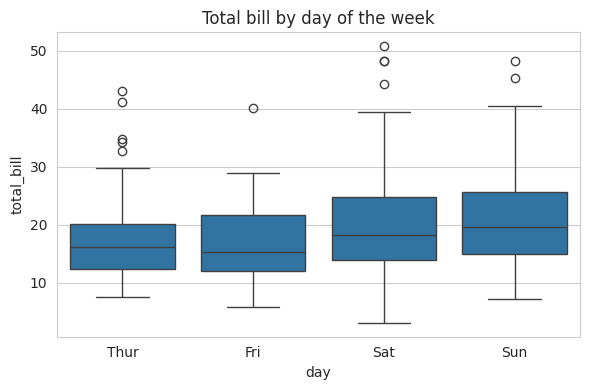

In [ ]:
# Quick visual: box plot of total bill by day
plt.figure(figsize=(6, 4))
sns.boxplot(data=tips, x="day", y="total_bill", order=["Thur", "Fri", "Sat", "Sun"])
plt.title("Total bill by day of the week")
plt.tight_layout()
plt.show()

**Try it yourself:** change the grouping above from `day` to `size` (party size) and re-run the ANOVA.

## 2. Correlation vs Causation

First, the classic ice-cream / drowning story with a small illustrative table.
Then a real check on the `tips` dataset.

In [ ]:
# A small illustrative dataset (not a real survey — just to show the idea clearly)
weather = pd.DataFrame({
    "month": ["Jan", "Apr", "Jul", "Oct"],
    "avg_temp_C": [12, 22, 34, 20],
    "ice_cream_sales_k": [8, 25, 58, 22],
    "drowning_incidents": [2, 6, 15, 5],
})
weather

,month,avg_temp_C,ice_cream_sales_k,drowning_incidents
0,Jan,12,8,2
1,Apr,22,25,6
2,Jul,34,58,15
3,Oct,20,22,5


In [28]:
# Correlation between ice-cream sales and drowning incidents
weather = pd.DataFrame({
    "month": ["Jan", "Apr", "Jul", "Oct"],
    "avg_temp_C": [12, 22, 34, 20],
    "ice_cream_sales_k": [8, 25, 58, 22],
    "drowning_incidents": [2, 6, 15, 5],
})
r, p_value = stats.pearsonr(weather["ice_cream_sales_k"], weather["drowning_incidents"])


# But both are also strongly correlated with temperature - the real driver
r_temp_ice, _ = stats.pearsonr(weather["avg_temp_C"], weather["ice_cream_sales_k"])
r_temp_drown, _ = stats.pearsonr(weather["avg_temp_C"], weather["drowning_incidents"])


### A real check: total bill vs tip in the `tips` dataset

Correlation between total bill and tip: r = 0.68


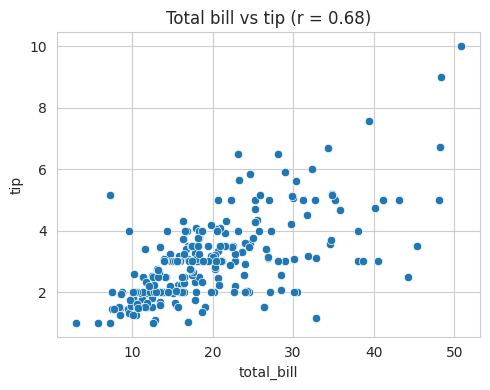

In [ ]:
r, p_value = stats.pearsonr(tips["total_bill"], tips["tip"])
print(f"Correlation between total bill and tip: r = {r:.2f}")

plt.figure(figsize=(5, 4))
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.title(f"Total bill vs tip (r = {r:.2f})")
plt.tight_layout()
plt.show()

**Try it yourself:** compute the correlation between `size` (party size) and `tip`. Can bigger bills explain part of it?

## 3. Central Limit Theorem & Sampling

We simulate a skewed population (like household income) and show that the
**sample means** still come out roughly normal.

Population mean: 796893
Population is skewed - look at the shape below


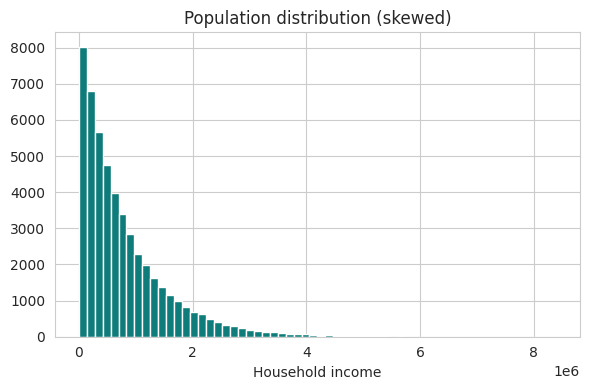

In [ ]:
np.random.seed(42)

# A skewed "population" - most values low, a long right tail (like income)
population = np.random.exponential(scale=800000, size=50000)

print("Population mean:", round(population.mean()))
print("Population is skewed - look at the shape below")

plt.figure(figsize=(6, 4))
plt.hist(population, bins=60, color="#0E7C7B")
plt.title("Population distribution (skewed)")
plt.xlabel("Household income")
plt.tight_layout()
plt.show()

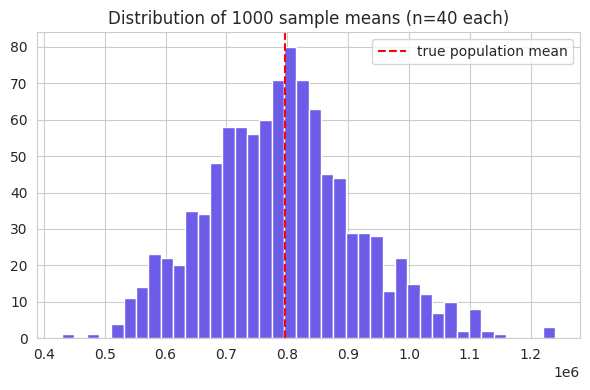

Mean of sample means: 791310
This looks like a bell curve, even though the population didn't!


In [ ]:
# Now draw 1,000 random samples of size 40, and record the MEAN of each sample
sample_size = 40
num_samples = 1000

sample_means = [np.random.choice(population, sample_size).mean() for _ in range(num_samples)]

plt.figure(figsize=(6, 4))
plt.hist(sample_means, bins=40, color="#6C5CE7")
plt.axvline(population.mean(), color="red", linestyle="--", label="true population mean")
plt.title(f"Distribution of {num_samples} sample means (n={sample_size} each)")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean of sample means:", round(np.mean(sample_means)))
print("This looks like a bell curve, even though the population didn't!")

**Try it yourself:** change `sample_size` to 5, then to 200, and re-run the cell above. Watch the bell curve get worse / better.

## 4. Bayes' Theorem Basics

### 4.1 The medical test example

In [ ]:
# Prior: how common is the disease in the population?
p_disease = 0.01          # 1% of people have it
p_positive_given_disease = 0.95   # test sensitivity
p_positive_given_healthy = 0.10   # false positive rate (1 - specificity)

p_healthy = 1 - p_disease

# P(positive test) = P(pos AND disease) + P(pos AND healthy)
p_positive = (p_positive_given_disease * p_disease) + (p_positive_given_healthy * p_healthy)

# Bayes' theorem: P(disease | positive test)
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print(f"P(disease | positive test) = {p_disease_given_positive:.1%}")

P(disease | positive test) = 8.8%


**Try it yourself:** change `p_disease` to `0.20` (a more common condition) and re-run. See how much the answer changes.

### 4.2 A tiny Naive Bayes spam example

In [ ]:
# Same logic as above, applied to spam filtering
p_spam = 0.30                     # 30% of incoming mail is spam (prior)
p_free_given_spam = 0.80          # word "free" appears in 80% of spam
p_free_given_ham = 0.05           # word "free" appears in 5% of genuine mail

p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)

p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | contains 'free') = {p_spam_given_free:.1%}")

P(spam | contains 'free') = 87.3%


In [ ]:
# A real (tiny) Naive Bayes classifier using scikit-learn, on a handful of toy emails
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

emails = [
    "free money now claim your prize",
    "win a free vacation click here",
    "meeting scheduled for tomorrow at 10am",
    "please review the attached report",
    "free free free limited offer buy now",
    "let's catch up over lunch next week",
]
labels = ["spam", "spam", "ham", "ham", "spam", "ham"]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

model = MultinomialNB()
model.fit(X, labels)

# Try it on a new email
new_email = ["free prize waiting, click now"]
prediction = model.predict(vectorizer.transform(new_email))
print("Prediction for:", new_email[0])
print("->", prediction[0])

Prediction for: free prize waiting, click now
-> spam


---
### Summary

| Concept | scipy/sklearn function used |
|---|---|
| t-test | `stats.ttest_ind` |
| Chi-square | `stats.chi2_contingency` |
| ANOVA | `stats.f_oneway` |
| Correlation | `stats.pearsonr` |
| CLT | plain numpy sampling loop |
| Bayes' theorem | plain arithmetic + `sklearn.naive_bayes.MultinomialNB` |

Go back to the handbook (`handbook.pdf`) for the plain-English explanation behind each of these.